# STOR 120: Midterm 1 Interactive Review Lab (Modules 00–07)

This notebook converts the Midterm 1 review session curriculum into an active coding lab[cite: 2]. 

**How to work through this lab:**
1. Read the conceptual summaries and method reference tables[cite: 2].
2. Fill in the code cells by replacing the ellipsis (`...`) placeholders with your code.
3. Run the automated check cells immediately below each question to test your code and verify your answers.

---
## Environment Setup
Run this cell first to import the course libraries and initialize matplotlib settings[cite: 1, 4, 5].

In [1]:
from datascience import *
import numpy as np
import matplotlib.pyplot as plots
%matplotlib inline
plots.style.use('fivethirtyeight')

print("✅ Setup complete! datascience and numpy are ready.")

✅ Setup complete! datascience and numpy are ready.


---
## Module 00: Table Manipulation & Operations

### Core Methods Reference
* `t.select('col1', 'col2')`: Returns a **new Table** containing only specified columns[cite: 2].
* `t.drop('col1', 'col2')`: Returns a **new Table** omitting specified columns[cite: 2].
* `t.sort('col', descending=False)`: Returns a **new Table** sorted by `'col'`[cite: 2].
* `t.where('col', predicate)`: Returns a **new Table** filtered by row condition[cite: 2].
* `t.column('col')`: Returns the raw **NumPy Array** for that column (not a table)[cite: 2].
* `t.take(row_indices)`: Returns a **new Table** containing only specified row indices[cite: 2].

> **Critical Rule:** Table methods return a **new copy** of the table without modifying the original in-place[cite: 1, 2]. Calling `.item()` on `.select()` causes an error because tables do not have an `.item()` method — use `.column('col').item(...)` instead[cite: 2].

### Question 0.1: Skyscraper Slicing & Method Chaining
Load `'Data/skyscrapers.csv'` into a table called `skyscrapers`[cite: 1, 2]. Write a single line of chained code to construct a table named `nyc_tallest` that:
1. Contains only skyscrapers located in `"New York City"`[cite: 2].
2. Retains only the `'name'` and `'height'` columns[cite: 2].
3. Is sorted from tallest to shortest by `'height'`[cite: 2].

In [2]:
skyscrapers = Table.read_table('../shared/Data/skyscrapers.csv')

# Write your single-line chained solution below:
nyc_tallest = skyscrapers.where("city", are.equal_to("New York City")).select("name", "height").sort("height", descending=True)
nyc_tallest.show(5)

name,height
One World Trade Center,541.3
432 Park Avenue,425.5
Empire State Building,381
Bank of America Tower,365.8
Chrysler Building,318.9


In [3]:
# Question 0.1 Check Cell
assert isinstance(nyc_tallest, Table), "nyc_tallest must be a Table object."
assert nyc_tallest.num_columns == 2, "nyc_tallest should have exactly 2 columns ('name' and 'height')."
assert list(nyc_tallest.labels) == ['name', 'height'], "Columns must be ['name', 'height'] in that order."
assert nyc_tallest.column('height').item(0) >= nyc_tallest.column('height').item(1), "nyc_tallest must be sorted descending by height."
print("✅ Question 0.1 passed!")

✅ Question 0.1 passed!


### Question 0.2: Expression Return Types
What is the exact data type of evaluating: `skyscrapers.take(np.arange(5)).column('height')`[cite: 2]?

Assign `q0_2_type` to one of: `'Table'`, `'NumPy Array'`, `'int'`, or `'float'`[cite: 2].

In [5]:
q0_2_type = "NumPy Array"
q0_2_type

'NumPy Array'

In [6]:
# Question 0.2 Check Cell
assert q0_2_type == 'NumPy Array', "Remember: .column() always returns a NumPy Array, even when chained after .take()!"
print("✅ Question 0.2 passed!")

✅ Question 0.2 passed!


### Question 0.3: Review Session Weather Table Queries
Run the cell below to load the `temps` table used in lecture review[cite: 17].

In [7]:
temps = Table().with_columns(
    'Station', make_array('Asheville', 'Boone', 'Durham', 'Wilmington', 'Charlotte'),
    'Region', make_array('Mountains', 'Mountains', 'Piedmont', 'Coastal', 'Piedmont'),
    'High', make_array(78, 71, 86, 89, 88),
    'Low', make_array(54, 48, 63, 70, 66),
    'Rainfall', make_array(3.9, 4.6, 3.2, 5.1, 3.4)
)
temps

Station,Region,High,Low,Rainfall
Asheville,Mountains,78,54,3.9
Boone,Mountains,71,48,4.6
Durham,Piedmont,86,63,3.2
Wilmington,Coastal,89,70,5.1
Charlotte,Piedmont,88,66,3.4


Using the `temps` table above, evaluate the following operations[cite: 17]:
1. `first_high`: The numerical result of `temps.column('High').item(0)`[cite: 17].
2. `piedmont_count`: The number of rows in `temps.where('Region', are.equal_to('Piedmont'))`[cite: 17].
3. `hottest_low_station`: Write a single line of code that sorts `temps` by `'Low'` in descending order and extracts the name of that station (`Station`)[cite: 17].

In [17]:
first_high = 78
piedmont_count = 2
hottest_low_station = temps.sort("Low", descending=True).column("Station").item(0)

first_high, piedmont_count, hottest_low_station

(78, 2, 'Wilmington')

In [18]:
# Question 0.3 Check Cell
assert first_high == 78, "first_high should be the 0th item in High: 78."
assert piedmont_count == 2, "There are 2 Piedmont rows (Durham and Charlotte)."
assert hottest_low_station == 'Wilmington', "Wilmington has the highest Low (70)."
print("✅ Question 0.3 passed!")

✅ Question 0.3 passed!


---
## Module 01: Data Types & Output Evaluation

| Expression | Return Data Type | Example Value |[cite: 2]
| :--- | :--- | :--- |[cite: 2]
| `table.num_rows` | `int` | `100` |[cite: 2]
| `table.labels` | `tuple` of strings | `('name', 'age')` |[cite: 2]
| `table.select('col')` | `Table` | 1-column Table |[cite: 2]
| `table.column('col')` | `numpy.ndarray` | `array([10, 20])` |[cite: 2]
| `array.item(0)` | Primitive (`int`/`float`/`str`) | `10` or `'NC'` |[cite: 2]
| `np.average(array)` | `float` | `85.4` |[cite: 2]

### Question 1.1: Return Type Identification
Assign each variable to the string `'int'`, `'float'`, or `'bool'` representing the return type of each expression[cite: 2]:
1. `3 + 4.0`[cite: 2]
2. `skyscrapers.num_rows > 50`[cite: 2]
3. `skyscrapers.column('height').item(0)`[cite: 2]

In [24]:
type_part1 = "float"
type_part2 = "bool"
type_part3 = "float" #type(skyscrapers.column("height").item(0))

type_part1, type_part2, type_part3

('float', 'bool', 'float')

In [25]:
# Question 1.1 Check Cell
assert type_part1.lower() == 'float', "Part 1: 3 + 4.0 evaluates to 7.0, which is a float."
assert type_part2.lower() == 'bool', "Part 2: Comparison operators (> , < , ==) return booleans (bool)."
assert type_part3.lower() in ['float', 'numpy.int64'], "Part 3: .item(0) extracts an integer height."
print("✅ Question 1.1 passed!")

✅ Question 1.1 passed!


---
## Module 02: Arrays, Ranges & Building Tables

### Question 2.1: Generating Ranges with `np.arange`
Write an expression using `np.arange` to generate the array: `array([15, 20, 25, 30, 35])`[cite: 2]. Assign this array to `by_fives`[cite: 2].

In [27]:
by_fives = np.arange(15, 40, 5)
by_fives

array([15, 20, 25, 30, 35])

In [28]:
# Question 2.1 Check Cell
assert isinstance(by_fives, np.ndarray), "by_fives must be a NumPy array."
assert np.array_equal(by_fives, make_array(15, 20, 25, 30, 35)), "Array must exactly equal [15, 20, 25, 30, 35]."
print("✅ Question 2.1 passed!")

✅ Question 2.1 passed!


### Question 2.2: Constructing Tables from Scratch
Construct a table called `cities` from scratch containing three columns[cite: 2]:
* `'City'`: `'Chapel Hill'`, `'Raleigh'`, `'Durham'`[cite: 2]
* `'Population'`: `61000`, `467000`, `283000`[cite: 2]
* `'County'`: `'Orange'`, `'Wake'`, `'Durham'`[cite: 2]

In [29]:
cities = Table().with_columns(
    'City', np.array(["Chapel Hill", "Raleigh", "Durham"]),
    'Population', np.array([61000, 467000, 283000]),
    'County', np.array(["Orange", "Wake", "Durham"])
)
cities

City,Population,County
Chapel Hill,61000,Orange
Raleigh,467000,Wake
Durham,283000,Durham


In [30]:
# Question 2.2 Check Cell
assert isinstance(cities, Table), "cities must be a Table."
assert cities.num_rows == 3, "cities must have 3 rows."
assert cities.num_columns == 3, "cities must have 3 columns."
assert list(cities.labels) == ['City', 'Population', 'County'], "Check your column labels."
print("✅ Question 2.2 passed!")

✅ Question 2.2 passed!


---
## Module 03: Visualization & Attribute Classification

### Question 3.1: Variable Classification
Classify each of the following variables as `'Categorical'`, `'Numerical (Continuous)'`, or `'Numerical (Discrete)'`[cite: 2]:
1. Student ID numbers (e.g., `730123456`)[cite: 2]
2. Time spent studying for Midterm 1 in hours (e.g., `4.5` hours)[cite: 2]
3. Number of questions answered correctly on a 20-question quiz[cite: 2]

In [35]:
student_id_type = "Categorical"
study_time_type = "Numerical (Continuous)"
quiz_score_type = "Numerical (Discrete)"

student_id_type, study_time_type, quiz_score_type

('Categorical', 'Numerical (Continuous)', 'Numerical (Discrete)')

In [36]:
# Question 3.1 Check Cell
assert student_id_type == 'Categorical', "Student IDs are numeric codes acting as category identifiers (differences are meaningless)."
assert study_time_type == 'Numerical (Continuous)', "Study time is continuous because it can take fractional values (4.512 hours)."
assert quiz_score_type == 'Numerical (Discrete)', "Quiz scores are countable whole integers (0, 1, 2, ...)."
print("✅ Question 3.1 passed!")

✅ Question 3.1 passed!


---
## Module 04: Chart Selection & Two-Variable Plotting

### Question 4.1: Choosing the Right Visualization
Assign each scenario to `'Scatter Plot'`, `'Line Graph'`, or `'Horizontal Bar Chart'`[cite: 2]:
1. Comparing the total gross revenue of the top 10 highest-grossing movies[cite: 2].
2. Tracking the daily closing stock price of Apple over 365 consecutive days[cite: 2].
3. Examining the relationship between student height and exam score[cite: 2].

In [37]:
chart_scenario_1 = "Horizontal Bar Chart"
chart_scenario_2 = "Line Graph"
chart_scenario_3 = "Scatter Plot"

chart_scenario_1, chart_scenario_2, chart_scenario_3

('Horizontal Bar Chart', 'Line Graph', 'Scatter Plot')

In [38]:
# Question 4.1 Check Cell
assert chart_scenario_1 == 'Horizontal Bar Chart', "Scenario 1: Categorical movie titles with numeric values require a bar chart."
assert chart_scenario_2 == 'Line Graph', "Scenario 2: Sequential chronological data over time requires a line plot."
assert chart_scenario_3 == 'Scatter Plot', "Scenario 3: Two numerical variables without temporal ordering require a scatter plot."
print("✅ Question 4.1 passed!")

✅ Question 4.1 passed!


### Question 4.2: Group Coloring in Scatter Plots
Using the `skyscrapers` table, create a scatter plot of `'completed'` (year, on the x-axis) versus `'height'` (on the y-axis), with data points color-coded by the `'material'` column[cite: 2].

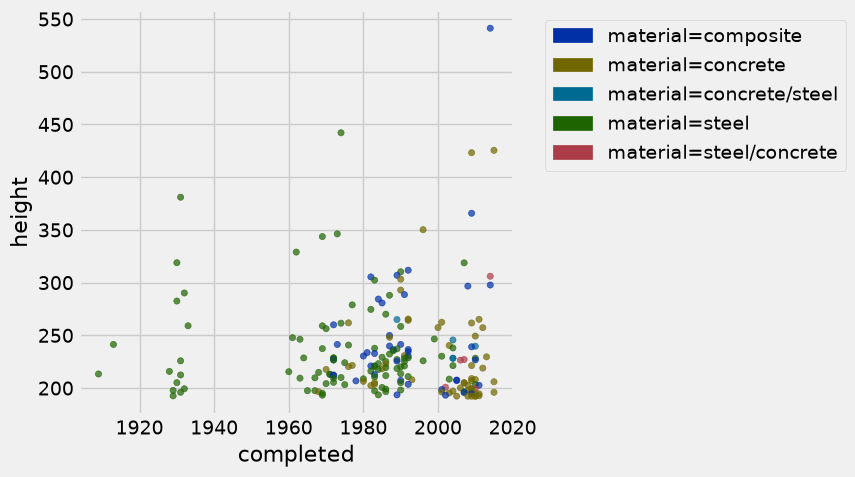

In [39]:
# Write the single line to generate the grouped scatter plot:
skyscrapers.scatter("completed", "height", group="material")


In [40]:
# Question 4.2 Check Cell
assert 'material' in skyscrapers.labels, "Check column names in skyscrapers."
print("✅ Question 4.2 passed! Confirm visually that points are colored by material.")

✅ Question 4.2 passed! Confirm visually that points are colored by material.


---
## Module 05: Density Histograms & The Area Principle

### Core Formulas
$\text{Area of Bar} = \text{Percent in Bin} = \text{Height} \times \text{Bin Width}$[cite: 2]
$\text{Height (Density)} = \frac{\text{Percent in Bin}}{\text{Bin Width}}$[cite: 2]
$\text{Bin Width} = \text{Upper Endpoint} - \text{Lower Endpoint}$[cite: 2]

### Question 5.1: Histogram Math
A density histogram of exam scores contains a bin `[70, 85)` with a bar height of **2.4% per point**[cite: 2].
1. Calculate the percentage of students in this bin. Assign to `pct_exam_bin`[cite: 2].
2. If 200 students took the exam, how many students scored in this bin? Assign to `count_exam_bin`[cite: 2].

In [44]:
pct_exam_bin = 2.4 * 15 
count_exam_bin =  200 * (pct_exam_bin / 100)

pct_exam_bin, count_exam_bin

(36.0, 72.0)

In [45]:
# Question 5.1 Check Cell
# Width = 85 - 70 = 15; Percent = 2.4 * 15 = 36.0%
assert pct_exam_bin == 36.0, "Bin width is 15. Percent = 2.4 * 15 = 36.0%."
assert count_exam_bin == 72, "Count = 0.36 * 200 = 72 students."
print("✅ Question 5.1 passed!")

✅ Question 5.1 passed!


---
## Module 06: User-Defined Functions & `.apply()`

### Question 6.1: Writing a Custom Function
Define a function `compute_tax(salary)` that takes a numerical salary and returns[cite: 2]:
* `salary * 0.20` if `salary > 100000`[cite: 2]
* `salary * 0.10` otherwise[cite: 2]

In [46]:
def compute_tax(salary):
    """Calculates tax based on salary threshold."""
    if salary > 100000:
        return salary * 0.20
    else:
        return salary * 0.10


In [47]:
# Question 6.1 Check Cell
assert compute_tax(120000) == 24000.0, "Failed for salary 120,000 (should be 20%)."
assert compute_tax(100000) == 10000.0, "Failed for salary 100,000 (boundary should be 10%)."
assert compute_tax(50000) == 5000.0, "Failed for salary 50,000 (should be 10%)."
print("✅ Question 6.1 passed!")

✅ Question 6.1 passed!


### Question 6.2: Applying Functions Across Columns
Run the cell below to initialize the `salaries` table[cite: 2].

In [48]:
salaries = Table().with_columns(
    'Employee', make_array('Alice', 'Bob', 'Charlie', 'Diana'),
    'Salary', make_array(110000, 85000, 150000, 95000)
)
salaries

Employee,Salary
Alice,110000
Bob,85000
Charlie,150000
Diana,95000


Use `.apply()` with your `compute_tax` function to add a new column `'Tax'` to `salaries`[cite: 2]. Assign the result to `salaries_with_tax`[cite: 2].

In [49]:
salaries_with_tax = salaries.with_column(
    'Tax', salaries.apply(compute_tax, "Salary")
)
salaries_with_tax

Employee,Salary,Tax
Alice,110000,22000
Bob,85000,8500
Charlie,150000,30000
Diana,95000,9500


In [50]:
# Question 6.2 Check Cell
assert isinstance(salaries_with_tax, Table), "salaries_with_tax must be a Table."
assert 'Tax' in salaries_with_tax.labels, "Missing 'Tax' column."
assert np.array_equal(salaries_with_tax.column('Tax'), make_array(22000.0, 8500.0, 30000.0, 9500.0)), "Tax values computed incorrectly."
print("✅ Question 6.2 passed!")

✅ Question 6.2 passed!


---
## Module 07: Data Aggregation (`.group()` & `.pivot()`)

### Syntax Comparison
* `table.group('category', np.mean)`: Groups by a single column and aggregates numerical columns[cite: 2, 7]. Renames columns to `'col mean'`[cite: 2, 7].
* `table.pivot('col_variable', 'row_variable', values='val_col', collect=np.mean)`: Cross-classifies into a 2D contingency grid[cite: 2, 7].

Run the cell below to load the student survey dataset[cite: 2].

In [51]:
survey = Table().with_columns(
    'major', make_array('STOR', 'COMP', 'STOR', 'COMP', 'STOR', 'COMP', 'STOR', 'COMP'),
    'class_standing', make_array('Freshman', 'Freshman', 'Sophomore', 'Sophomore', 'Junior', 'Junior', 'Senior', 'Senior'),
    'gpa', make_array(3.4, 3.8, 3.2, 3.6, 3.9, 3.1, 3.7, 3.5)
)
survey

major,class_standing,gpa
STOR,Freshman,3.4
COMP,Freshman,3.8
STOR,Sophomore,3.2
COMP,Sophomore,3.6
STOR,Junior,3.9
COMP,Junior,3.1
STOR,Senior,3.7
COMP,Senior,3.5


### Question 7.1: Cross-Classifying with `.pivot()`
Construct a pivot table where[cite: 2]:
* Rows represent each `'major'`[cite: 2]
* Columns represent each `'class_standing'`[cite: 2]
* Grid cells contain the average `'gpa'` for that combination[cite: 2]

Assign the resulting table to `gpa_pivot`[cite: 2].

In [53]:
# Note: 1st argument is the column variable, 2nd argument is the row variable
gpa_pivot = survey.pivot("class_standing", "major", values="gpa", collect=np.mean)
gpa_pivot

major,Freshman,Junior,Senior,Sophomore
COMP,3.8,3.1,3.5,3.6
STOR,3.4,3.9,3.7,3.2


In [ ]:
# Question 7.1 Check Cell
assert isinstance(gpa_pivot, Table), "gpa_pivot must be a Table."
assert gpa_pivot.num_rows == 2, "There should be 2 rows (COMP and STOR)."
assert 'Freshman' in gpa_pivot.labels and 'Senior' in gpa_pivot.labels, "Columns must represent class standings."
assert 'major' in gpa_pivot.labels, "First column must be 'major'."
print("✅ Question 7.1 passed!")

### Question 7.2: Group Aggregations
Using the `survey` table, calculate the average GPA for each `major`[cite: 2]. Retain only `'major'` and `'gpa'` before grouping[cite: 2, 7]. Assign the table to `gpa_by_major`[cite: 2].

In [56]:
gpa_by_major = survey.select('major', 'gpa').group("major", np.mean)
gpa_by_major

major,gpa mean
COMP,3.5
STOR,3.55


In [57]:
# Question 7.2 Check Cell
assert isinstance(gpa_by_major, Table), "gpa_by_major must be a Table."
assert gpa_by_major.num_rows == 2, "There are 2 majors."
assert 'gpa mean' in gpa_by_major.labels, "Aggregated column should be named 'gpa mean'."
assert np.isclose(gpa_by_major.where('major', 'COMP').column('gpa mean').item(0), 3.5), "COMP mean should be 3.5."
assert np.isclose(gpa_by_major.where('major', 'STOR').column('gpa mean').item(0), 3.55), "STOR mean should be 3.55."
print("✅ Question 7.2 passed!")

✅ Question 7.2 passed!


---
## Congratulations! You've Completed the Midterm 1 Review Lab!
To ensure all code blocks execute without bugs, select **Kernel -> Restart Kernel and Run All Cells**[cite: 4].